In [1]:
from wrf import uvmet, to_np, getvar, interplevel, smooth2d, get_cartopy, cartopy_xlim, cartopy_ylim, latlon_coords
import numpy as np
from netCDF4 import Dataset
import xarray as xr
from metpy.units import units
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
from matplotlib.colors import from_levels_and_colors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
from cartopy.feature import NaturalEarthFeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from cartopy.mpl.gridliner import LATITUDE_FORMATTER, LONGITUDE_FORMATTER
import cmaps
from glob import glob
import metpy.calc as mpcalc
import metpy.constants as constants

TypeError: deprecated() got an unexpected keyword argument 'name'

In [3]:
# 用 netCDF4 包读取 WRF 模拟数据
wrf_file = Dataset(
"E:/000_FuJian/wrfout_FuJian/C6_mp6_cu14/c6_d02.nc")
# 提取要素
lon = getvar(wrf_file, 'lon')
lat = getvar(wrf_file, 'lat')
u = getvar(wrf_file, 'ua')
v = getvar(wrf_file, 'va')
q = getvar(wrf_file, 'QVAPOR')
z = getvar(wrf_file, 'z')
# 提取WRF模拟的经纬度数组
lats, lons = latlon_coords(u)

# 提取WRF模拟的地图投影
wrf_proj = get_cartopy(u)

In [4]:
p = getvar(wrf_file, 'pressure')
u850 = interplevel(u, p, 850)
v850 = interplevel(v, p, 850)
q850 = interplevel(q, p, 850) 
z850 = interplevel(z, p, 850) 
## 混合比转为比湿
q850 = q850/(1+q850)

dx, dy = mpcalc.lat_lon_grid_deltas(lon, lat)
# 计算水汽通量散度
q_flux_divergence = mpcalc.divergence(
    to_np(
        u850 *
        q850/constants.g),
    to_np(
        v850 *
        q850/constants.g),
    dx=to_np(dx),
    dy=to_np(dy))

In [5]:
q_flux_divergence


Magnitude,[[-3.4534826208337234e-07 -1.0617784210482511e-07 3.578874327674713e-08 ... 2.5749263294372115e-08 2.525587219161792e-08 2.4175920120809363e-08] [-5.546560324127987e-08 1.1002139437692723e-07 1.7702683342807752e-07 ... 2.8504569207420238e-08 2.812715476206657e-08 2.727126903747041e-08] [1.4025452349324174e-07 2.5941590039395934e-07 2.9387459985863214e-07 ... 3.184381621496825e-08 3.1694856669661417e-08 3.100071437644394e-08] ... [-1.4621368241836852e-07 -1.7187131818654586e-07 -1.624806384781383e-07 ... 7.991506331460315e-08 6.376942097217535e-08 4.7979252009184825e-08] [-8.817854360841693e-08 -1.4034165255945537e-07 -1.496309270825229e-07 ... 9.194986385517257e-08 7.599686590424944e-08 6.103943426876793e-08] [-1.3607276047419597e-08 -5.765346728114889e-08 -8.704251283128012e-08 ... 1.014968023807079e-07 8.652588561166909e-08 7.28426102169937e-08]]
Units,1/meter


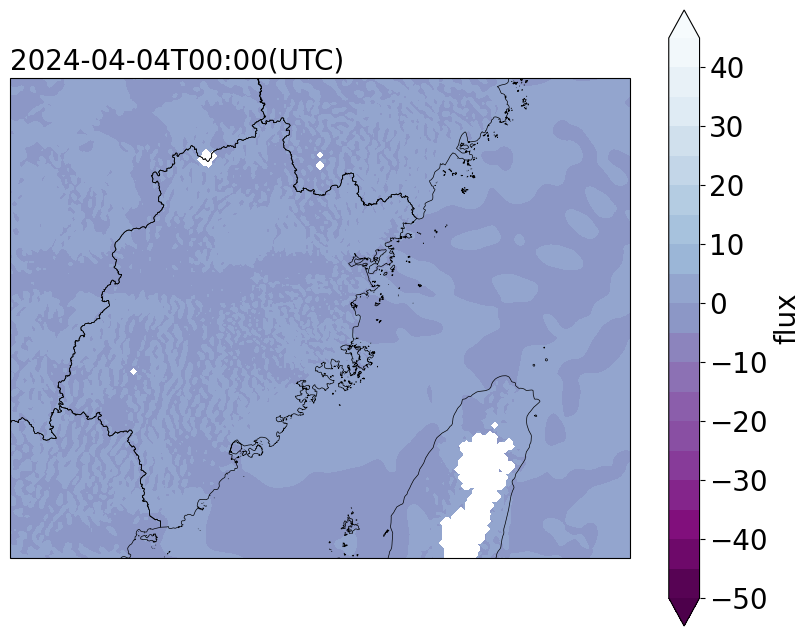

In [6]:
import frykit.plot as fplt
# 创建画布
fig = plt.figure(figsize=(10, 8))
# 设置地图投影
ax = plt.axes(projection=wrf_proj)
# 设置地图范围
ax.set_xlim(cartopy_xlim(u))
ax.set_ylim(cartopy_ylim(u))
# 绘制分布（用contourf方法实现等值线填充）
plt.contourf(to_np(lons),
             to_np(lats),
             to_np(q_flux_divergence),
             levels=np.arange(-50, 50, 5),
             extend='both',
             transform=ccrs.PlateCarree(),
             cmap=cmaps.MPL_BuPu_r)
# 添加colorbar
cbar = plt.colorbar(ax=ax, extend='both', shrink=1)
cbar.set_label('flux', fontdict={'size': 20})
cbar.ax.tick_params(labelsize=20)
fplt.add_cn_province(ax)
# 设置刻度标签的字体大小
plt.tick_params(labelsize=15)
# 添加标题
plt.title(str(u.Time.values)[0:16]+'(UTC)', loc='left', fontsize=20)
plt.show()

In [7]:
levels = [1000,925,850,700,600,500,400,300]
zinterp = interplevel(z, p, levels)
zinterp 

<xarray.DataArray 'height_interp' (level: 8, south_north: 207, west_east: 267)>
array([[[        nan,         nan,         nan, ...,  118.87288 ,
          119.11775 ,  119.356735],
        [        nan,         nan,         nan, ...,  118.667915,
          118.91777 ,  119.16616 ],
        [        nan,         nan,         nan, ...,  118.46677 ,
          118.72557 ,  118.97398 ],
        ...,
        [        nan,         nan,         nan, ...,  137.02171 ,
          136.68427 ,  136.3731  ],
        [        nan,         nan,         nan, ...,  137.21103 ,
          136.87929 ,  136.58496 ],
        [        nan,         nan,         nan, ...,  137.34631 ,
          137.02701 ,  136.74832 ]],

       [[ 785.4542  ,  790.80566 ,  792.0848  , ...,  800.3173  ,
          800.58417 ,  800.8456  ],
        [ 788.8096  ,  788.69574 ,  788.0566  , ...,  800.108   ,
          800.3862  ,  800.6609  ],
        [ 790.2198  ,  787.254   ,  784.48364 , ...,  799.9037  ,
          800.1971  ,  800.4713  ],
...
        [7483.767   , 7484.3657  , 7484.131   , ..., 7499.623   ,
         7500.019   , 7500.397   ],
        [7482.2593  , 7482.3027  , 7482.3843  , ..., 7499.187   ,
         7499.5894  , 7500.001   ],
        [7481.425   , 7480.6357  , 7480.95    , ..., 7498.784   ,
         7499.1978  , 7499.6143  ]],

       [[9658.785   , 9663.433   , 9664.552   , ..., 9679.533   ,
         9679.595   , 9679.668   ],
        [9661.385   , 9661.33    , 9660.741   , ..., 9679.019   ,
         9679.086   , 9679.159   ],
        [9662.156   , 9659.276   , 9656.275   , ..., 9678.516   ,
         9678.591   , 9678.675   ],
        ...,
        [9551.663   , 9551.515   , 9551.449   , ..., 9576.523   ,
         9576.888   , 9577.256   ],
        [9551.662   , 9551.674   , 9551.617   , ..., 9576.196   ,
         9576.578   , 9576.978   ],
        [9549.111   , 9549.666   , 9550.696   , ..., 9575.863   ,
         9576.269   , 9576.675   ]]], dtype=float32)
Coordinates:
    XLONG    (south_north, west_east) float32 115.3 115.3 115.4 ... 123.3 123.3
    XLAT     (south_north, west_east) float32 23.17 23.17 23.17 ... 28.72 28.72
    XTIME    float32 0.0
    Time     datetime64[ns] 2024-04-04
  * level    (level) int32 1000 925 850 700 600 500 400 300
Dimensions without coordinates: south_north, west_east
Attributes:
    FieldType:      104
    units:          m
    stagger:        
    coordinates:    XLONG XLAT XTIME
    projection:     LambertConformal(stand_lon=119.19999694824219, moad_cen_l...
    missing_value:  9.969209968386869e+36
    _FillValue:     9.969209968386869e+36
    vert_units:     hPa

In [8]:
u_interp = interplevel(u, p, levels)
v_interp = interplevel(v, p, levels)
q_interp = interplevel(q, p, levels) 
## 混合比转换比湿
q_interp = q_interp/(1+q_interp)
lev = u_interp.level

# 计算水汽通量散度
qu = u_interp *q_interp/constants.g
qv = v_interp *q_interp/constants.g
q_flux_divergence_all = np.zeros((lev.shape[0],lat.shape[0],lon.shape[1]))
for i in range(lev.shape[0]):
    q_flux_divergence_all[i] = mpcalc.divergence(u = to_np(qu[i]),v = to_np(qv[i]),dx = to_np(dx) ,dy = to_np(dy),x_dim=-1, y_dim=-2)

# 将 q_flux_divergence_all 中的 NaN 值替换为 0
q_flux_divergence_all = np.nan_to_num(q_flux_divergence_all, nan=0)
total_div_qv = np.trapz(q_flux_divergence_all,lev,axis=0)
total_div_qv[2]

array([-1.19186078e-05, -3.20444929e-05, -3.88895819e-05, -3.48774066e-05,
       -2.72167487e-05, -6.71652729e-06,  1.52050712e-05,  2.36681872e-05,
        1.08163390e-05, -3.94205551e-06, -9.06879089e-06, -1.15232013e-05,
       -1.73349493e-05, -1.96556161e-05,  1.53591819e-05,  1.06550122e-05,
       -3.02692732e-05, -2.96957362e-05,  6.36114961e-07, -9.34712148e-06,
       -5.13179805e-05, -3.51938712e-05, -1.94988322e-06,  1.90128241e-06,
       -6.16591809e-06, -1.62202102e-05, -1.70064459e-05, -8.25520134e-06,
        1.44656577e-05,  3.58887126e-05,  2.84074838e-05,  1.01037563e-05,
       -8.09693932e-06, -1.56200120e-05, -1.46276957e-05, -6.12123154e-06,
       -2.94356556e-06, -8.88953330e-07,  2.81993104e-06,  2.71863054e-06,
       -3.08050434e-06, -8.64070134e-06, -7.43472610e-06, -3.64842191e-06,
       -4.71326121e-06, -4.19397651e-06,  2.09112857e-06,  4.86593455e-06,
        1.27074687e-07, -3.30495993e-06, -8.75898584e-07,  2.16204775e-06,
        1.57535961e-06,  

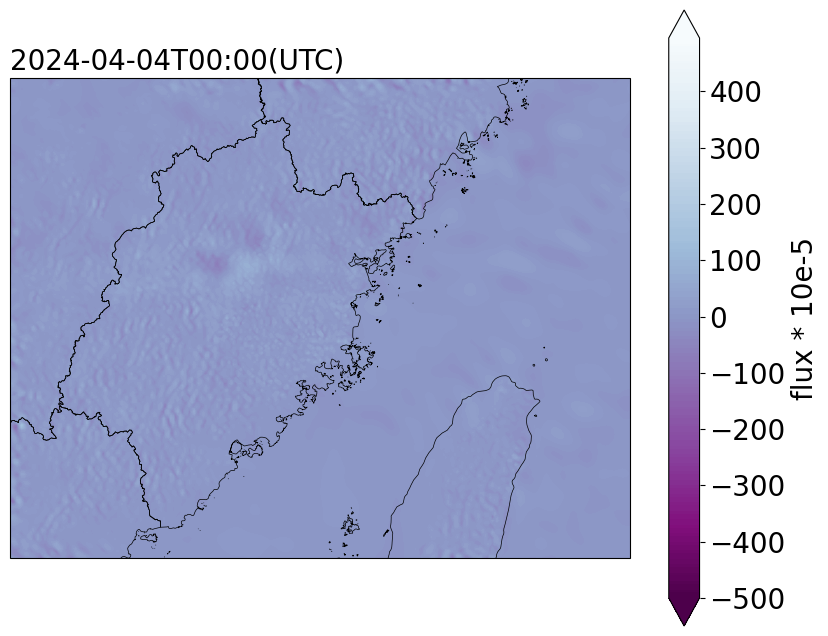

In [9]:
# 创建画布
fig = plt.figure(figsize=(10, 8))
# 设置地图投影
ax = plt.axes(projection=wrf_proj)
# 设置地图范围
ax.set_xlim(cartopy_xlim(u))
ax.set_ylim(cartopy_ylim(u))
# 用contourf方法实现等值线填充）
plt.contourf(to_np(lons),
             to_np(lats),
             to_np(total_div_qv*10e5),
             levels=np.arange(-500, 500, 5),
             extend='both',
             transform=ccrs.PlateCarree(),
             cmap=cmaps.MPL_BuPu_r)
# 添加colorbar
cbar = plt.colorbar(ax=ax, extend='both', shrink=1)
cbar.set_label('flux * 10e-5', fontdict={'size': 20})
cbar.ax.tick_params(labelsize=20)
fplt.add_cn_province(ax)
# 设置刻度标签的字体大小
plt.tick_params(labelsize=15)
# 添加标题
plt.title(str(u.Time.values)[0:16]+'(UTC)', loc='left', fontsize=20)
plt.show()